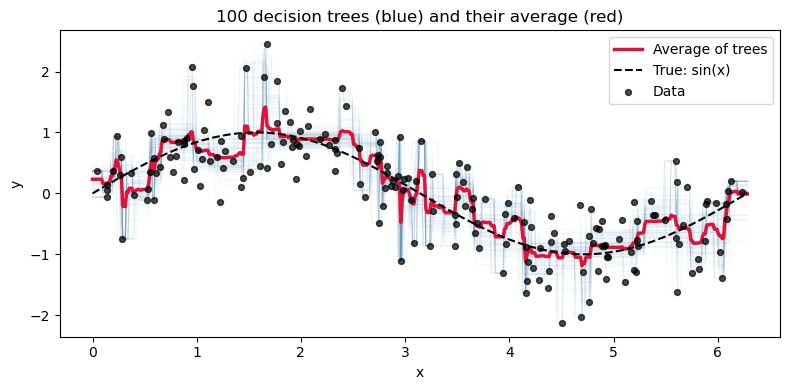

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

rng = np.random.default_rng(42)

# --- Data ---
n = 200
x = np.sort(rng.uniform(0, 2 * np.pi, n))
y = np.sin(x) + rng.normal(0, 0.5, n)

x_grid = np.linspace(0, 2 * np.pi, 500)

# --- Fit many trees on bootstrap samples ---
n_trees = 100
tree_preds = np.zeros((n_trees, len(x_grid)))

for i in range(n_trees):
    idx = rng.integers(0, n, size=n)
    tree = DecisionTreeRegressor(max_depth=5)
    tree.fit(x[idx].reshape(-1, 1), y[idx])
    tree_preds[i] = tree.predict(x_grid.reshape(-1, 1))

avg_pred = tree_preds.mean(axis=0)

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 4))

# individual trees (faint)
for i in range(n_trees):
    ax.plot(x_grid, tree_preds[i], color="steelblue", alpha=0.04, linewidth=0.8)

# average
ax.plot(x_grid, avg_pred, color="crimson", linewidth=2.5, label="Average of trees")

# true function
ax.plot(x_grid, np.sin(x_grid), color="black", linewidth=1.5, linestyle="--", label="True: sin(x)")

# data
ax.scatter(x, y, color="black", s=18, zorder=5, alpha=0.7, label="Data")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"{n_trees} decision trees (blue) and their average (red)")
ax.legend()
plt.tight_layout()
plt.savefig("fig/lec6_trees_avg.png", dpi=150)
plt.show()
